In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "Madhavan S2103"
os.environ["KAGGLE_API_TOKEN"] = "KGAT_b7fa5ef796e8adad6c304f386ba37429"

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d ismailpromus/skin-diseases-image-dataset


Dataset URL: https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset
License(s): copyright-authors
100% 5.19G/5.19G [00:55<00:00, 100MB/s] 



In [ ]:
!unzip -q skin-diseases-image-dataset.zip -d skin_dataset

In [ ]:
import os

dataset_path = "/content/skin_dataset/IMG_CLASSES"

print(os.listdir(dataset_path))

['10. Warts Molluscum and other Viral Infections - 2103', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '5. Melanocytic Nevi (NV) - 7970', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '4. Basal Cell Carcinoma (BCC) 3323', '1. Eczema 1677', '6. Benign Keratosis-like Lesions (BKL) 2624', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k']


In [ ]:
classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))

Number of Classes: 10


In [ ]:
for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

1. 10. Warts Molluscum and other Viral Infections - 2103
2. 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
3. 7. Psoriasis pictures Lichen Planus and related diseases - 2k
4. 5. Melanocytic Nevi (NV) - 7970
5. 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
6. 4. Basal Cell Carcinoma (BCC) 3323
7. 1. Eczema 1677
8. 6. Benign Keratosis-like Lesions (BKL) 2624
9. 2. Melanoma 15.75k
10. 3. Atopic Dermatitis - 1.25k


In [ ]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    class_counts[class_name] = image_count

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

10. Warts Molluscum and other Viral Infections - 2103: 2103
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055
5. Melanocytic Nevi (NV) - 7970: 7970
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847
4. Basal Cell Carcinoma (BCC) 3323: 3323
1. Eczema 1677: 1677
6. Benign Keratosis-like Lesions (BKL) 2624: 2079
2. Melanoma 15.75k: 3140
3. Atopic Dermatitis - 1.25k: 1257


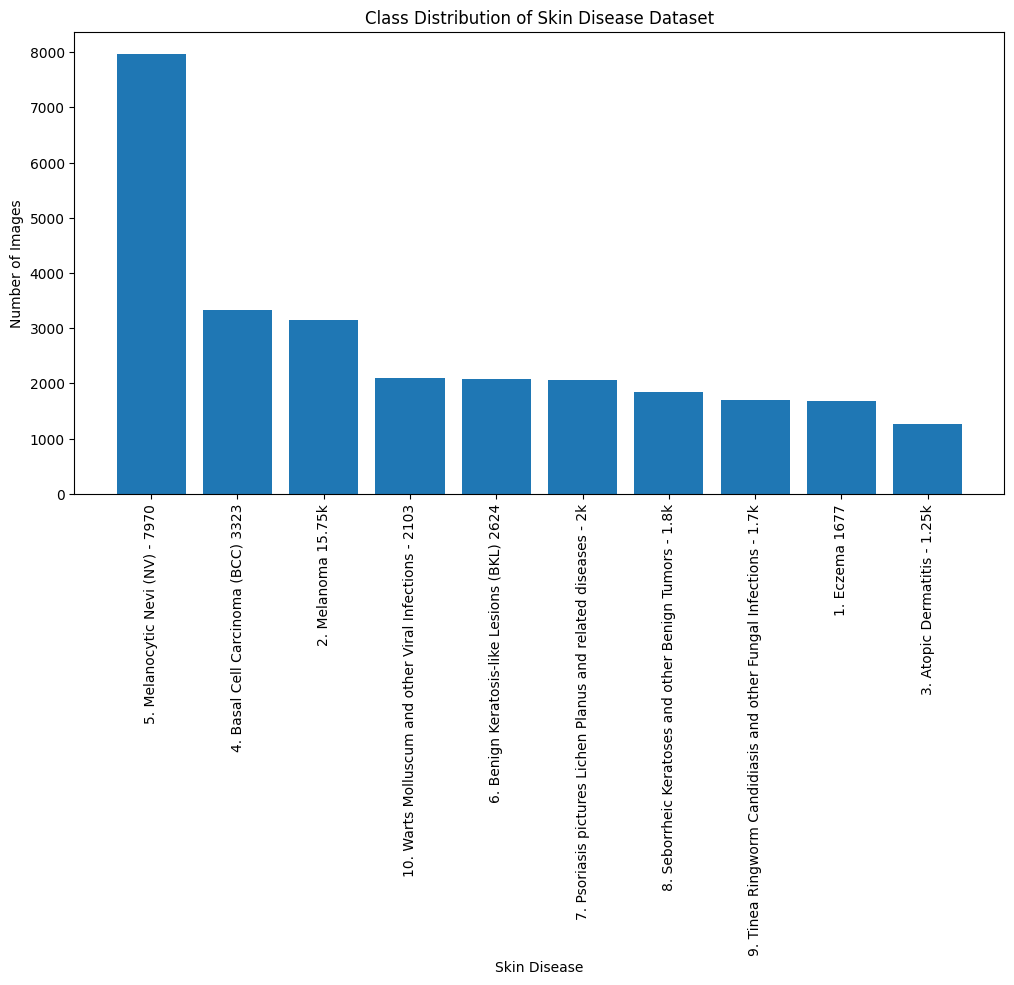

In [ ]:
import matplotlib.pyplot as plt

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12,6))

plt.bar(sorted_counts.keys(), sorted_counts.values())

plt.xticks(rotation=90)
plt.xlabel("Skin Disease")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Skin Disease Dataset")

plt.show()

In [ ]:
import pandas as pd

image_paths = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, image_name))
        labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [ ]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

In [ ]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [ ]:
print("Training Images   :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images    :", len(test_df))

Training Images   : 19007
Validation Images : 4073
Testing Images    : 4073


In [ ]:
class_names = sorted(df["label"].unique())

label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

index_to_label = {
    index: label
    for label, index in label_to_index.items()
}

print(label_to_index)

{'1. Eczema 1677': 0, '10. Warts Molluscum and other Viral Infections - 2103': 1, '2. Melanoma 15.75k': 2, '3. Atopic Dermatitis - 1.25k': 3, '4. Basal Cell Carcinoma (BCC) 3323': 4, '5. Melanocytic Nevi (NV) - 7970': 5, '6. Benign Keratosis-like Lesions (BKL) 2624': 6, '7. Psoriasis pictures Lichen Planus and related diseases - 2k': 7, '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': 8, '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': 9}


In [ ]:
train_df["label"] = train_df["label"].map(label_to_index)

val_df["label"] = val_df["label"].map(label_to_index)

test_df["label"] = test_df["label"].map(label_to_index)

In [ ]:
train_df.head()

,image_path,label
16090,/content/skin_dataset/IMG_CLASSES/4. Basal Cel...,4
8318,/content/skin_dataset/IMG_CLASSES/5. Melanocyt...,5
2669,/content/skin_dataset/IMG_CLASSES/9. Tinea Rin...,9
26044,/content/skin_dataset/IMG_CLASSES/3. Atopic De...,3
7790,/content/skin_dataset/IMG_CLASSES/5. Melanocyt...,5


In [ ]:
import tensorflow as tf
IMG_SIZE = (224, 224)
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label"].values)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)

In [ ]:
BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)


Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.6189948892674617), 1: np.float64(1.2912364130434784), 2: np.float64(0.8647406733393994), 3: np.float64(2.1598863636363634), 4: np.float64(0.8171539122957867), 5: np.float64(0.3406882953934397), 6: np.float64(1.3063230240549828), 7: np.float64(1.3208478109798472), 8: np.float64(1.4699922660479505), 9: np.float64(1.595885810243493)}


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,474 (27.86 MB)

 Trainable params: 264,970 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_skin_disease_model.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 182s 251ms/step - accuracy: 0.3650 - loss: 1.8267 - val_accuracy: 0.5421 - val_loss: 1.2847 - learning_rate: 1.0000e-04
Epoch 2/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 108s 182ms/step - accuracy: 0.5087 - loss: 1.4283 - val_accuracy: 0.5829 - val_loss: 1.1333 - learning_rate: 1.0000e-04
Epoch 3/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 143s 184ms/step - accuracy: 0.5476 - loss: 1.3130 - val_accuracy: 0.6094 - val_loss: 1.0566 - learning_rate: 1.0000e-04
Epoch 4/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 108s 182ms/step - accuracy: 0.5837 - loss: 1.2283 - val_accuracy: 0.6194 - val_loss: 1.0046 - learning_rate: 1.0000e-04
Epoch 5/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 110s 185ms/step - accuracy: 0.5985 - loss: 1.1824 - val_accuracy: 0.6290 - val_loss: 0.9797 - learning_rate: 1.0000e-04
Epoch 6/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 108s 182ms/step - accuracy: 0.6209 - loss: 1.1418 - val_accuracy: 0.6381 - val_loss: 0.9534 - learning_rate: 1.0000e-04
Epoch 7/30
594/594 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)


print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 147ms/step - accuracy: 0.7189 - loss: 0.7580
Test Loss: 0.7580
Test Accuracy: 0.7189


In [ ]:
model.save("SkinDiseaseCNN.keras")

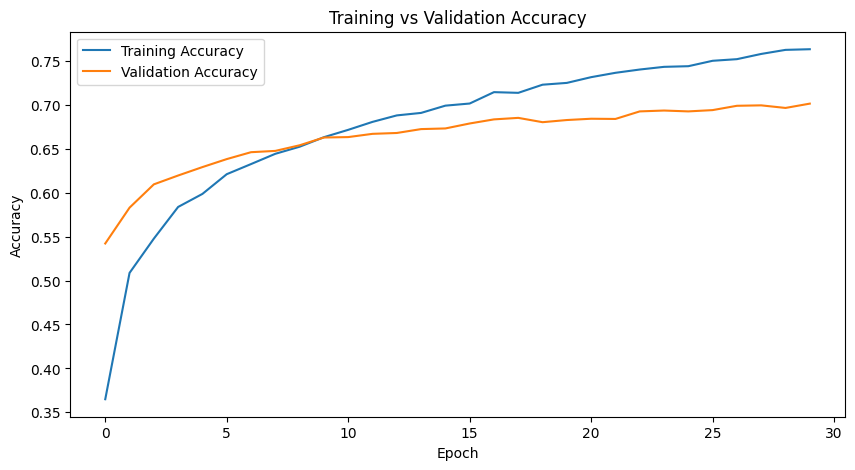

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

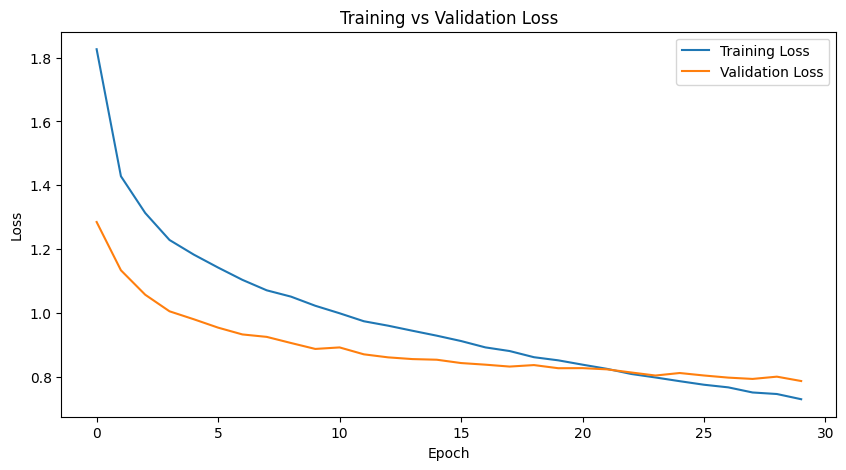

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[131  17   0  17   0   0   0  31  16  40]
 [ 13 184   0  31   0   0   1  18  32  36]
 [  1   0 409   0   7  41  13   0   0   0]
 [ 18  27   1 109   1   1   0  13   6  13]
 [  0   0   2   2 416  12  67   0   0   0]
 [  0   3  65   0  30 987 105   1   3   1]
 [  0   1   7   1  57  42 204   0   0   0]
 [ 32  24   1  40   1   0   0 137  29  44]
 [  8  22   0   5   1   3   4  19 197  18]
 [ 20  14   0  16   0   0   1  32  18 154]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.59      0.52      0.55       252
           10. Warts Molluscum and other Viral Infections - 2103       0.63      0.58      0.61       315
                                              2. Melanoma 15.75k       0.84      0.87      0.86       471
                                    3. Atopic Dermatitis - 1.25k       0.49      0.58      0.53       189
                              4. Basal Cell Carcinoma (BCC) 3323       0.81      0.83      0.82       499
                                 5. Melanocytic Nevi (NV) - 7970       0.91      0.83      0.87      1195
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.52      0.65      0.58       312
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.55      0.44      0.49       308
          8. Seborrheic Keratoses and other B